# Netflix Dataset - Cleaning, Analysis & Visualization
### Dataset: 8,790 titles | 10 Columns
---

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ── Styling ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
NETFLIX_RED   = '#E50914'
NETFLIX_DARK  = '#141414'
PALETTE       = ['#E50914', '#831010', '#FF6B6B', '#C0392B', '#922B21',
                 '#F1948A', '#EC7063', '#A93226', '#6E2F2F', '#B03A2E']

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


---
## 2. Load Dataset

In [7]:
df = pd.read_csv('D:\\Shamoun\\COURSES\\Data Analysis\\Projects Portfolio\\Data\\05-Python Portfolio\\03-Netflix Data\\netflix1.csv')
print(f'Rows   : {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows   : 8,790
Columns: 10


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


---
## 3. Data Cleaning

### 1 - Missing Values

In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

# Fill missing text columns with 'Unknown'
for col in ['director', 'country', 'rating']:
    df[col] = df[col].fillna('Unknown')

print('\n✅ Missing values handled.')

              Missing Count  Missing %
show_id                   0        0.0
type                      0        0.0
title                     0        0.0
director                  0        0.0
country                   0        0.0
date_added                0        0.0
release_year              0        0.0
rating                    0        0.0
duration                  0        0.0
listed_in                 0        0.0

✅ Missing values handled.


### 2 - Parse `date_added` → datetime

In [16]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name']  = df['date_added'].dt.strftime('%b')

print('date_added sample:')
print(df[['date_added', 'year_added', 'month_added', 'month_name']].head())

date_added sample:
  date_added  year_added  month_added month_name
0 2021-09-25        2021            9        Sep
1 2021-09-24        2021            9        Sep
2 2021-09-24        2021            9        Sep
3 2021-09-22        2021            9        Sep
4 2021-09-24        2021            9        Sep


### 3 - Extract numeric `duration_mins` for Movies

In [17]:
# Movies → minutes (int) | TV Shows → number of seasons (int)
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

movies_df  = df[df['type'] == 'Movie'].copy()
tvshows_df = df[df['type'] == 'TV Show'].copy()

print(f'Movies  : {len(movies_df):,}')
print(f'TV Shows: {len(tvshows_df):,}')
print(f'\nDuplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)
print('✅ Duplicates removed.')

Movies  : 6,126
TV Shows: 2,664

Duplicate rows: 0
✅ Duplicates removed.


### 4 - Strip extra whitespace from string columns

In [18]:
str_cols = df.select_dtypes('object').columns
for col in str_cols:
    df[col] = df[col].str.strip()

print('✅ Whitespace stripped from all string columns.')
print('\n🗂  Final cleaned dataset shape:', df.shape)

✅ Whitespace stripped from all string columns.

🗂  Final cleaned dataset shape: (8790, 14)


---
## 4. Exploratory Data Analysis

### 1 - Basic Statistics

In [19]:
print('=== Numeric Summary ===')
print(df[['release_year', 'duration_int']].describe().round(2))

print('\n=== Type Distribution ===')
print(df['type'].value_counts())

print('\n=== Top 10 Countries ===')
print(df['country'].value_counts().head(10))

print('\n=== Top 10 Ratings ===')
print(df['rating'].value_counts().head(10))

=== Numeric Summary ===
       release_year  duration_int
count       8790.00       8790.00
mean        2014.18         69.93
std            8.83         50.79
min         1925.00          1.00
25%         2013.00          2.00
50%         2017.00         88.50
75%         2019.00        106.00
max         2021.00        312.00

=== Type Distribution ===
type
Movie      6126
TV Show    2664
Name: count, dtype: int64

=== Top 10 Countries ===
country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

=== Top 10 Ratings ===
rating
TV-MA    3205
TV-14    2157
TV-PG     861
R         799
PG-13     490
TV-Y7     333
TV-Y      306
PG        287
TV-G      220
NR         79
Name: count, dtype: int64


### 2 - Top Genres

In [20]:
# Each title can have multiple genres separated by ', '
all_genres = [g.strip() for row in df['listed_in'] for g in row.split(',')]
genre_counts = Counter(all_genres)
top_genres = pd.DataFrame(genre_counts.most_common(15), columns=['Genre', 'Count'])
print(top_genres)

                       Genre  Count
0       International Movies   2752
1                     Dramas   2426
2                   Comedies   1674
3     International TV Shows   1349
4              Documentaries    869
5         Action & Adventure    859
6                  TV Dramas    762
7         Independent Movies    756
8   Children & Family Movies    641
9            Romantic Movies    616
10                 Thrillers    577
11               TV Comedies    573
12            Crime TV Shows    469
13                  Kids' TV    448
14                Docuseries    394


---
## 5. Visualizations

### 1 - Movies vs TV Shows (Pie)

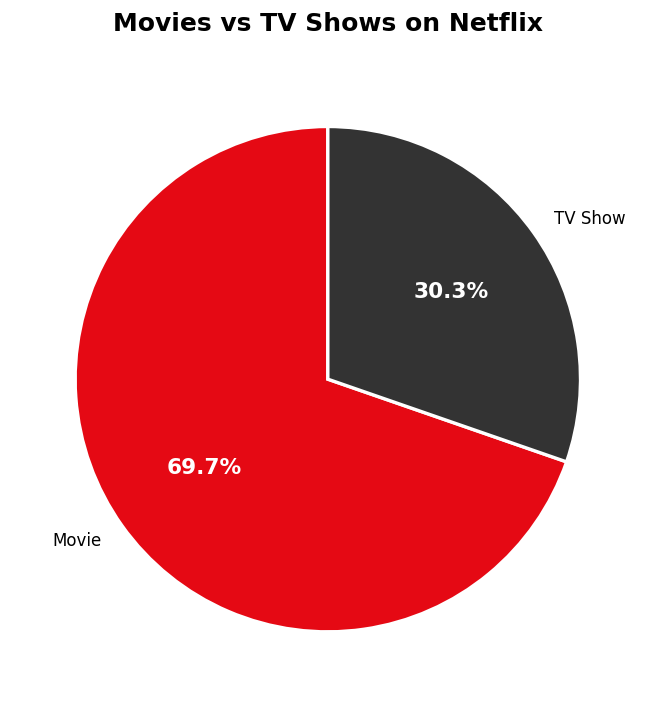

In [21]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(6, 6))
wedges, texts, autotexts = ax.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=[NETFLIX_RED, '#333333'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_color('white')
    at.set_fontweight('bold')

ax.set_title('Movies vs TV Shows on Netflix', fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('plot_01_type_distribution.png', bbox_inches='tight')
plt.show()

### 2 - Content Added Per Year

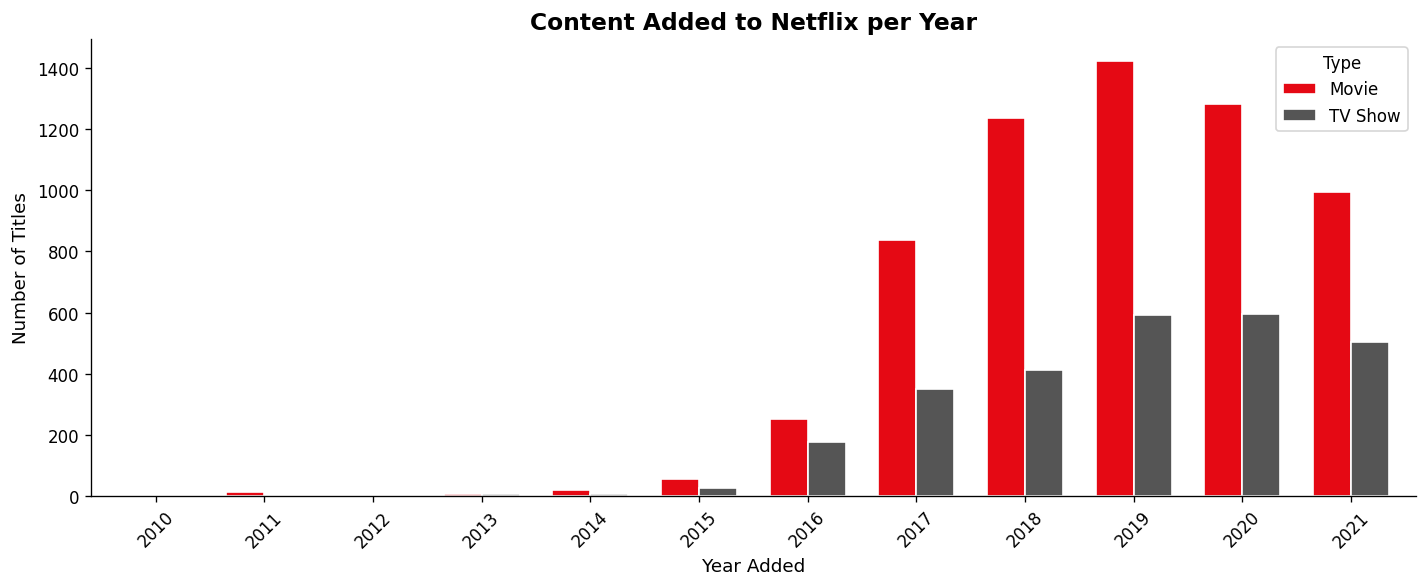

In [22]:
yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]

fig, ax = plt.subplots(figsize=(12, 5))
yearly.plot(kind='bar', ax=ax, color=[NETFLIX_RED, '#555555'], edgecolor='white', width=0.7)
ax.set_title('Content Added to Netflix per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year Added', fontsize=11)
ax.set_ylabel('Number of Titles', fontsize=11)
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Type')
ax.yaxis.set_major_locator(mticker.MultipleLocator(200))
plt.tight_layout()
plt.savefig('plot_02_content_per_year.png', bbox_inches='tight')
plt.show()

### 3 - Top 10 Countries by Content Volume

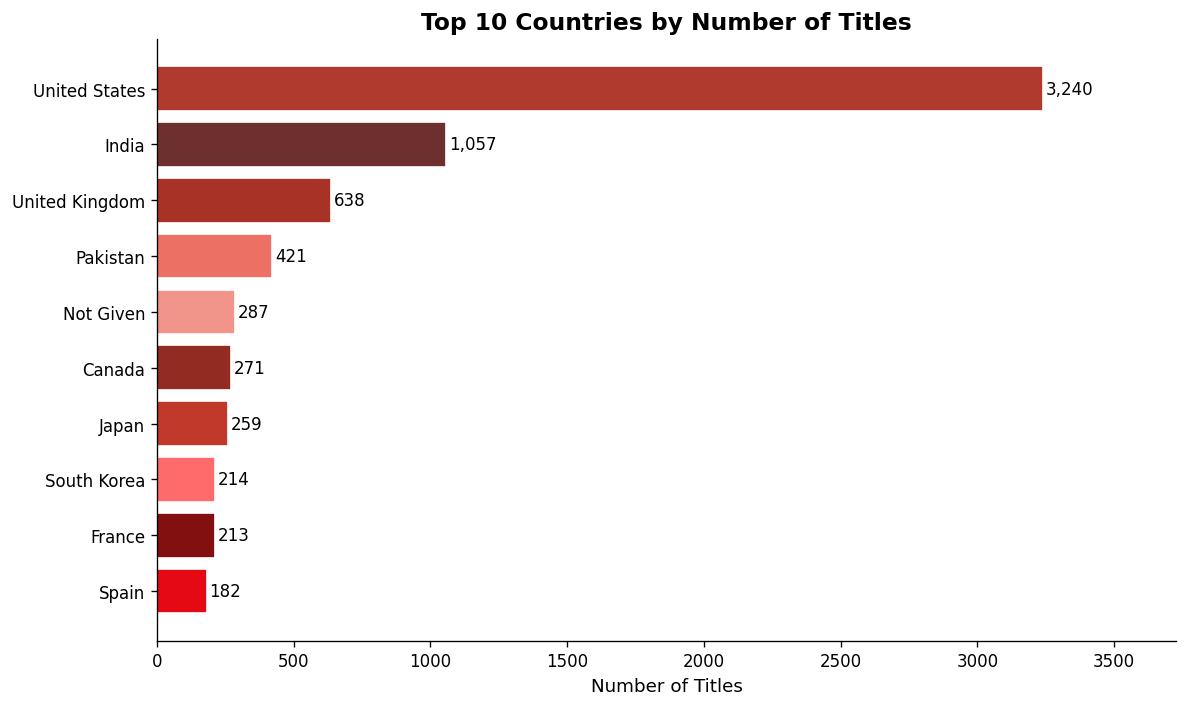

In [23]:
top_countries = (
    df[df['country'] != 'Unknown']['country']
    .value_counts()
    .head(10)
    .reset_index()
)
top_countries.columns = ['Country', 'Count']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_countries['Country'][::-1], top_countries['Count'][::-1],
               color=PALETTE[:10], edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)

ax.set_title('Top 10 Countries by Number of Titles', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=11)
ax.set_xlim(0, top_countries['Count'].max() * 1.15)
plt.tight_layout()
plt.savefig('plot_03_top_countries.png', bbox_inches='tight')
plt.show()

### 4 - Top 15 Genres

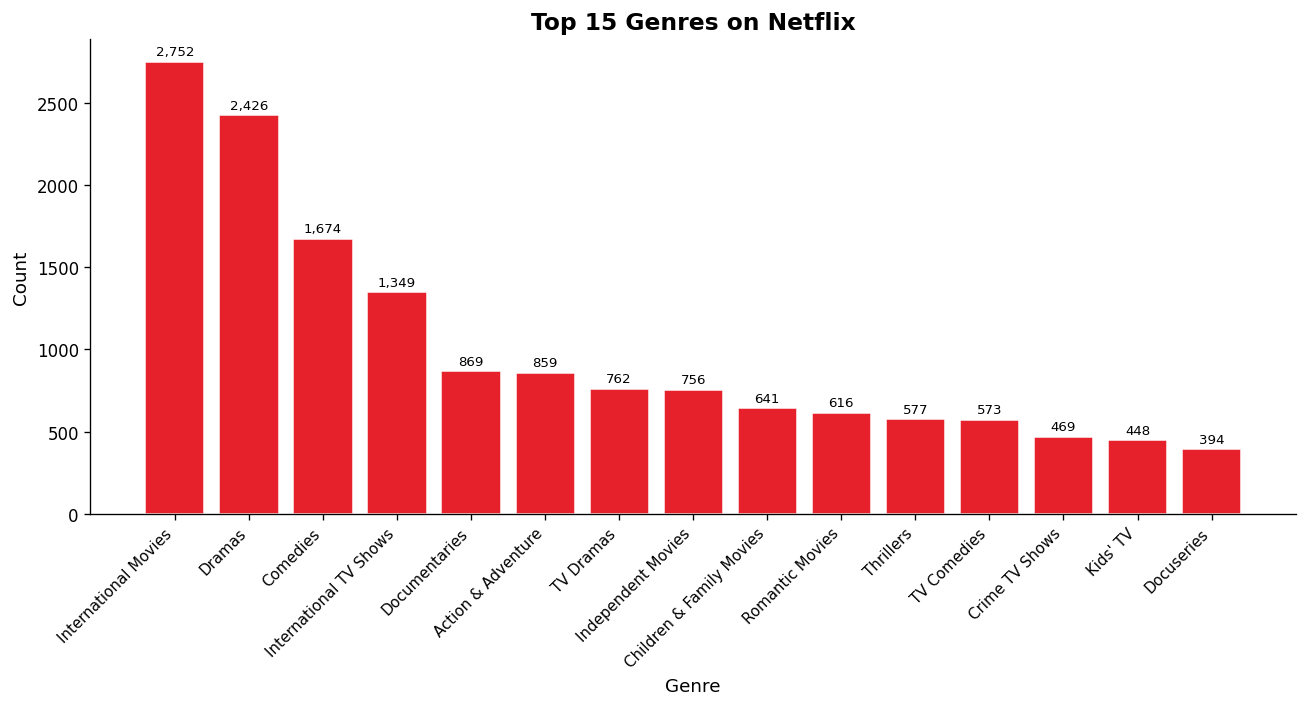

In [24]:
fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(top_genres['Genre'], top_genres['Count'],
              color=NETFLIX_RED, edgecolor='white', alpha=0.9)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=8)

ax.set_title('Top 15 Genres on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('plot_04_top_genres.png', bbox_inches='tight')
plt.show()

### 5 - Content Ratings Distribution

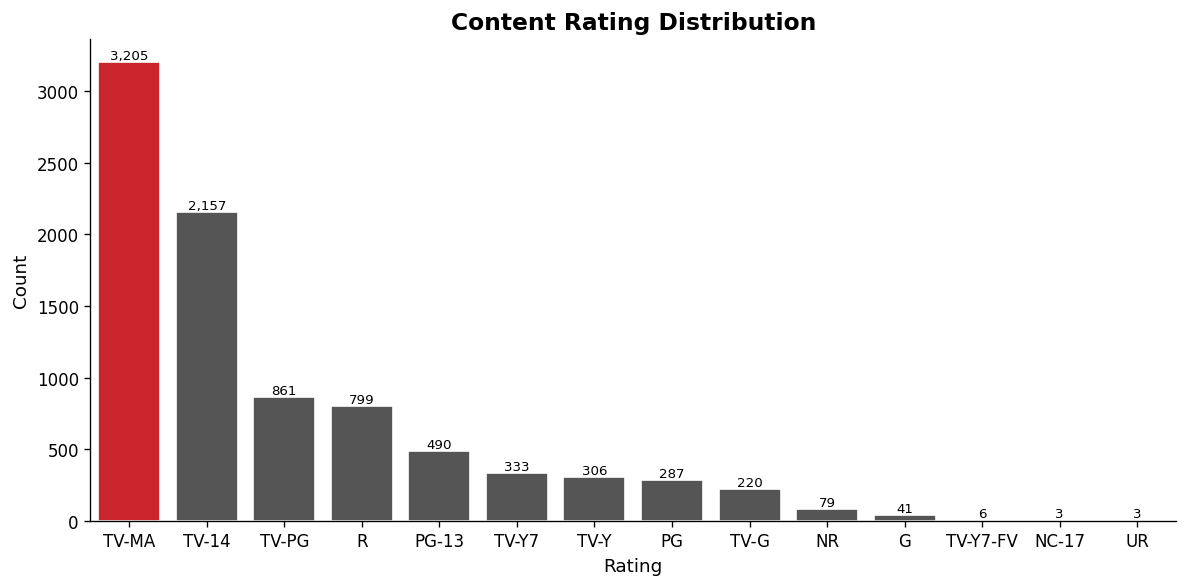

In [25]:
rating_counts = df[df['rating'] != 'Unknown']['rating'].value_counts().reset_index()
rating_counts.columns = ['Rating', 'Count']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=rating_counts, x='Rating', y='Count',
            palette=['#E50914' if i == 0 else '#555555' for i in range(len(rating_counts))],
            ax=ax, edgecolor='white')
ax.set_title('Content Rating Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('plot_05_ratings.png', bbox_inches='tight')
plt.show()

### 6 - Movie Duration Distribution

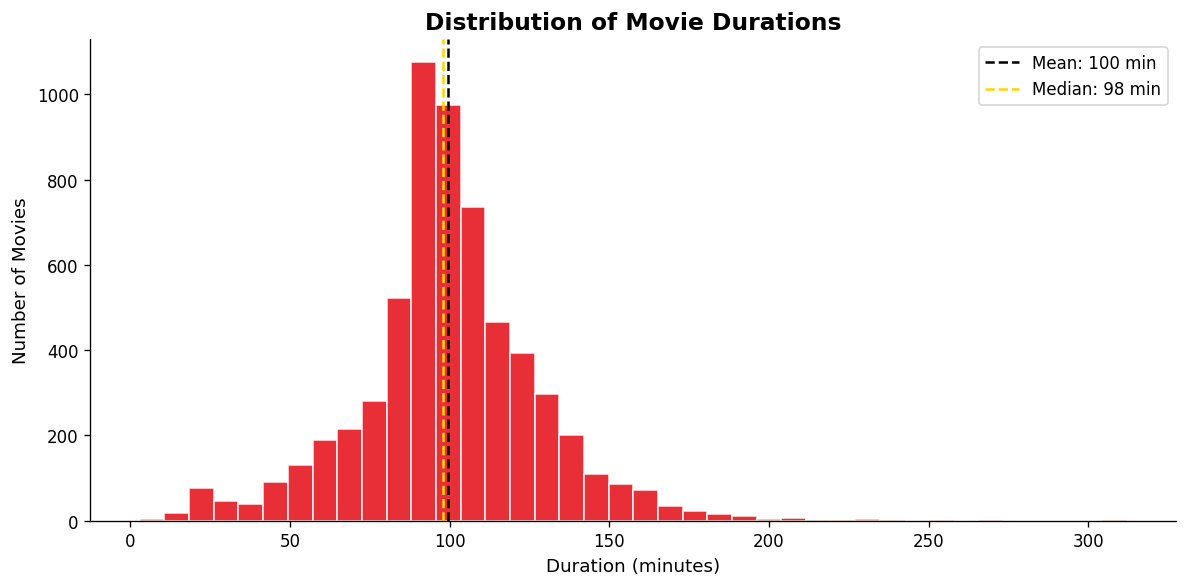

In [26]:
movie_durations = movies_df['duration_int'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(movie_durations, bins=40, color=NETFLIX_RED, edgecolor='white', alpha=0.85)
ax.axvline(movie_durations.mean(), color='black', linestyle='--', linewidth=1.5,
           label=f'Mean: {movie_durations.mean():.0f} min')
ax.axvline(movie_durations.median(), color='gold', linestyle='--', linewidth=1.5,
           label=f'Median: {movie_durations.median():.0f} min')
ax.set_title('Distribution of Movie Durations', fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (minutes)', fontsize=11)
ax.set_ylabel('Number of Movies', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('plot_06_movie_duration.png', bbox_inches='tight')
plt.show()

### 7 - TV Shows by Number of Seasons

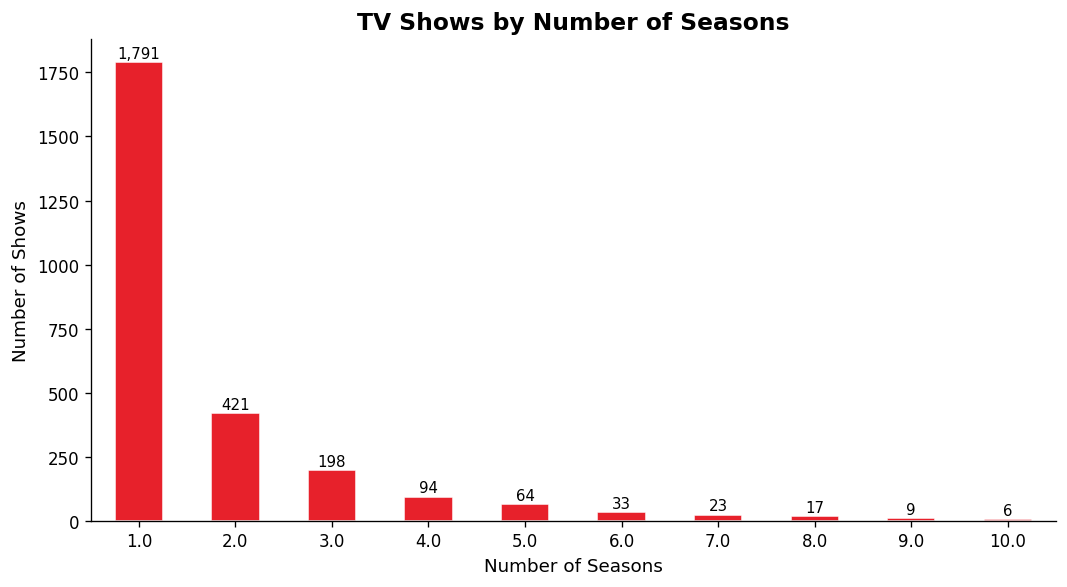

In [27]:
seasons_counts = tvshows_df['duration_int'].dropna().value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
seasons_counts.plot(kind='bar', ax=ax, color=NETFLIX_RED, edgecolor='white', alpha=0.9)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width()/2, p.get_height() + 5),
                ha='center', va='bottom', fontsize=9)
ax.set_title('TV Shows by Number of Seasons', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Seasons', fontsize=11)
ax.set_ylabel('Number of Shows', fontsize=11)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('plot_07_tv_seasons.png', bbox_inches='tight')
plt.show()

### 8 - Monthly Content Additions (Heatmap)

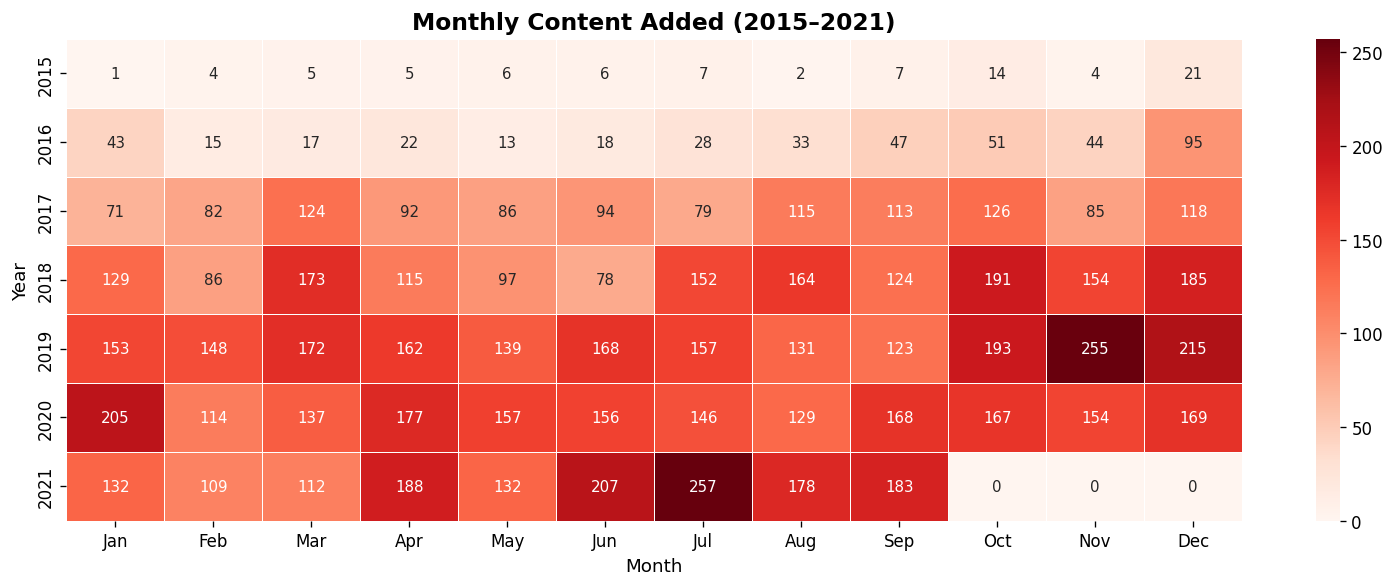

In [28]:
heatmap_data = (
    df.dropna(subset=['year_added', 'month_added'])
    .groupby(['year_added', 'month_added'])
    .size()
    .unstack(fill_value=0)
)
heatmap_data = heatmap_data[heatmap_data.index >= 2015]
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                         'Jul','Aug','Sep','Oct','Nov','Dec'][:len(heatmap_data.columns)]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_data, cmap='Reds', linewidths=0.5,
            annot=True, fmt='d', annot_kws={'size': 9}, ax=ax)
ax.set_title('Monthly Content Added (2015–2021)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
plt.tight_layout()
plt.savefig('plot_08_monthly_heatmap.png', bbox_inches='tight')
plt.show()

### 9 - Release Year Trend (Movies vs TV Shows)

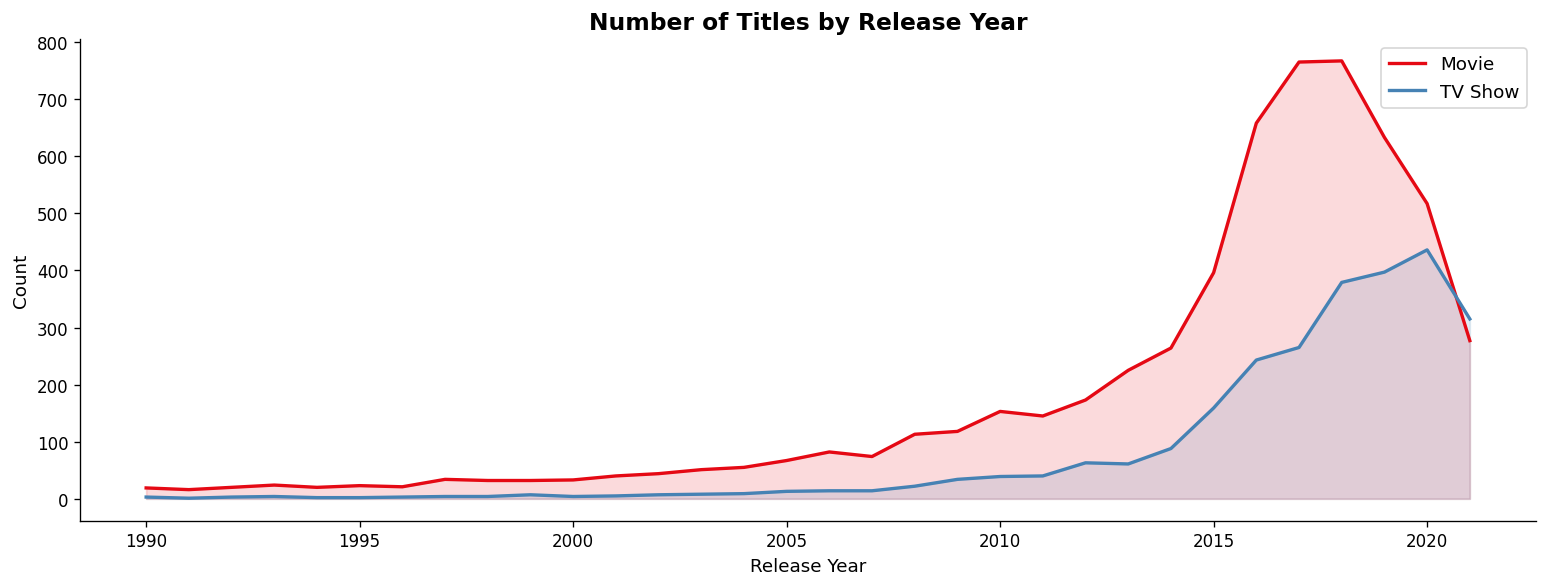

In [29]:
release_trend = (
    df[df['release_year'] >= 1990]
    .groupby(['release_year', 'type'])
    .size()
    .unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(13, 5))
release_trend['Movie'].plot(ax=ax, color=NETFLIX_RED, linewidth=2, label='Movie')
release_trend['TV Show'].plot(ax=ax, color='steelblue', linewidth=2, label='TV Show')
ax.fill_between(release_trend.index, release_trend['Movie'], alpha=0.15, color=NETFLIX_RED)
ax.fill_between(release_trend.index, release_trend['TV Show'], alpha=0.15, color='steelblue')
ax.set_title('Number of Titles by Release Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('plot_09_release_year_trend.png', bbox_inches='tight')
plt.show()

### 10 - Top 10 Directors by Title Count

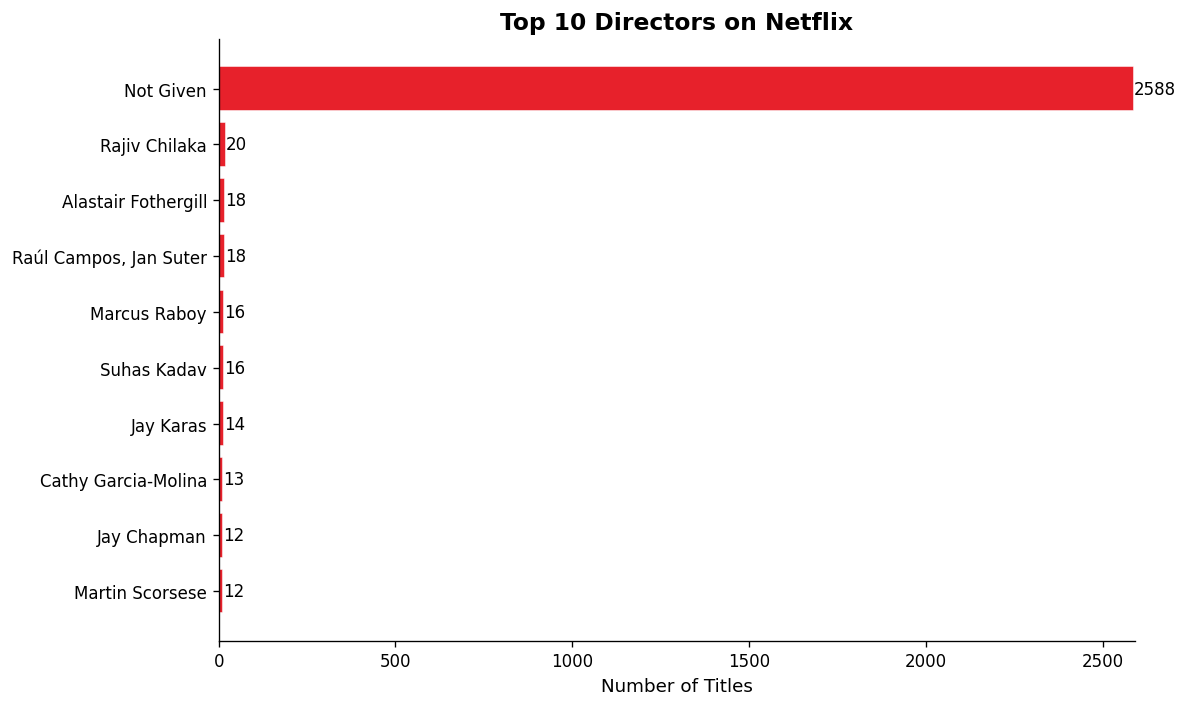

In [30]:
top_directors = (
    df[df['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
    .reset_index()
)
top_directors.columns = ['Director', 'Count']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_directors['Director'][::-1], top_directors['Count'][::-1],
               color=NETFLIX_RED, edgecolor='white', alpha=0.9)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)

ax.set_title('Top 10 Directors on Netflix', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=11)
ax.set_xlim(0, top_directors['Count'].max() + 3)
plt.tight_layout()
plt.savefig('plot_10_top_directors.png', bbox_inches='tight')
plt.show()

---
## 6. Summary & Key Insights

In [31]:
print('=' * 55)
print('     🎬  NETFLIX DATASET - KEY INSIGHTS')
print('=' * 55)
print(f"  Total Titles        : {len(df):,}")
print(f"  Movies              : {len(movies_df):,} ({len(movies_df)/len(df)*100:.1f}%)")
print(f"  TV Shows            : {len(tvshows_df):,} ({len(tvshows_df)/len(df)*100:.1f}%)")
print(f"  Date Range Added    : {df['year_added'].min():.0f} – {df['year_added'].max():.0f}")
print(f"  Release Year Range  : {df['release_year'].min()} – {df['release_year'].max()}")
print(f"  Avg Movie Duration  : {movies_df['duration_int'].mean():.0f} minutes")
print(f"  Top Country         : {df[df['country']!='Unknown']['country'].value_counts().idxmax()}")
print(f"  Most Common Rating  : {df[df['rating']!='Unknown']['rating'].value_counts().idxmax()}")
print(f"  Most Common Genre   : {top_genres.iloc[0]['Genre']}")
print(f"  Peak Year Added     : {df['year_added'].value_counts().idxmax():.0f}")
print('=' * 55)

     🎬  NETFLIX DATASET - KEY INSIGHTS
  Total Titles        : 8,790
  Movies              : 6,126 (69.7%)
  TV Shows            : 2,664 (30.3%)
  Date Range Added    : 2008 – 2021
  Release Year Range  : 1925 – 2021
  Avg Movie Duration  : 100 minutes
  Top Country         : United States
  Most Common Rating  : TV-MA
  Most Common Genre   : International Movies
  Peak Year Added     : 2019
